#### Install packages

In [1]:
! pip install darts matplotlib seaborn pandas --quiet

#### Import libraries

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from darts import TimeSeries
from darts.utils.statistics import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
NUM_SERIES  = 25
NUM_DISPLAY = 4
SEED        = 4212

### Read data and select NUM_SERIES random series to predict

In [126]:
# Path to TSF file
tsf_file = "m4_daily_dataset.tsf"

# Read file
with open(tsf_file, 'r', encoding='ISO-8859-1') as f:
    lines = f.readlines()

# Find start of data section
data_start = next(i for i, line in enumerate(lines) if line.strip() == "@data")
data_lines = lines[data_start + 1:]

# Parse all series
series_list = []
for line in data_lines:
    if not line.strip():
        continue
    parts = line.strip().split(':')
    start_timestamp = pd.to_datetime(parts[1], format='%Y-%m-%d %H-%M-%S')
    values = [float(x) for x in parts[2].split(',') if x != '']
    dates = pd.date_range(start=start_timestamp, periods=len(values), freq='D')
    series = pd.Series(values, index=dates)
    series_list.append(series)

# Sort by length and take top 100
series_list = sorted(series_list, key=lambda s: len(s), reverse=True)[:NUM_SERIES]

darts_series_list = []
for s in series_list:
    ts = TimeSeries.from_series(s, freq="D")
    pd_ts = ts.to_series().bfill()
    ts = TimeSeries.from_series(pd_ts, freq="D")
    darts_series_list.append(ts)

In [ ]:
np.random.seed(SEED)

# Pick 4 random series
random_series_list = np.random.choice(NUM_DISPLAY, darts_series_list)

# Plot them in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ts in enumerate(random_series_list):
    ax = axes[i]
    ts.to_series().plot(ax=ax, color='blue')
    ax.set_title(f"Random Series {i+1}", fontsize=10)

    # Weekly ticks in red
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=24))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_color('red')
        tick.label1.set_fontsize(8)

    # Rotate x-axis labels vertically
    plt.setp(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.


#### Basic stats for each item in random series

In [ ]:
stats = []
for i, series in enumerate(random_series_list, start=1):
    stats.append({
        "Series": f"Random Series {i}",
        "Start": series.start_time(),
        "End": series.end_time(),
        "Length": len(series),
        "Frequency": series.freq,
        "Mean": series.mean().values()[0],
        "Min": series.min().values()[0],
        "Max": series.max().values()[0]
    })

# Create DataFrame
df_stats = pd.DataFrame(stats)

# Display table
display(df_stats)

,Series,Start,End,Length,Frequency,Mean,Min,Max
0,Random Series 1,2000-01-03 12:00:00,2012-02-13 12:00:00,4425,<Day>,[1222.1],[1222.1],[1222.1]
1,Random Series 2,2000-01-03 12:00:00,2012-07-06 12:00:00,4569,<Day>,[6019.6],[6019.6],[6019.6]
2,Random Series 3,2000-01-03 12:00:00,2012-02-13 12:00:00,4425,<Day>,[1821.9],[1821.9],[1821.9]
3,Random Series 4,2000-01-03 12:00:00,2012-03-13 12:00:00,4454,<Day>,[246.54],[246.54],[246.54]


#### Stationarity (ADF Test) for each item in random series


$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \varepsilon_t$


Where:
\begin{aligned}
& y_t && \text{is the value of the time series at time } t, \\
& \Delta y_t && = y_t - y_{t-1} \text{ (first difference)}, \\
& \alpha && \text{is the constant (drift term)}, \\
& \beta t && \text{is the deterministic trend component}, \\
& \gamma && \text{is the coefficient for lagged level term}, \\
& \delta_i && \text{are coefficients for lagged differences}, \\
& p && \text{is the number of lag terms}, \\
& \varepsilon_t && \text{is the error term}.
\end{aligned}

Hypotheses:
\begin{aligned}
& H_0: \gamma = 0 \quad \text{(series has a unit root, non-stationary)} \\
& H_1: \gamma < 0 \quad \text{(series is stationary)}
\end{aligned}

In [ ]:
stats = []
for i, series in enumerate(random_series_list, start=1):
    values = series.values().flatten()
    adf_result = adfuller(values)
    stats.append({"ADF Statistic:":adf_result[0].round(2),
                  "p-value":adf_result[1].round(2),
                  "Critical Value (L)":adf_result[4]['1%'].round(2),
                  "Critical Value (R)":adf_result[4]['5%'].round(2)

    })

df_stats = pd.DataFrame(stats)

# Display table
display(df_stats)

,ADF Statistic:,p-value,Critical Value (L),Critical Value (R)
0,-0.09,0.95,-3.43,-2.86
1,-1.88,0.34,-3.43,-2.86
2,-1.71,0.43,-3.43,-2.86
3,-1.90,0.33,-3.43,-2.86


#### ACF and PACF visualization

$
\text{ACF at lag } k: \quad \rho_k = \frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T} (y_t - \bar{y})^2} \\
\text{Where: } \bar{y} \text{ is the mean of the series, and } T \text{ is the total number of observations.}
$




$ \text{PACF at lag } k: \quad \phi_{kk} \text{ is the coefficient of } y_{t-k} \text{ in the linear regression: }
y_t = \alpha + \sum_{i=1}^{k} \phi_{ki} y_{t-i} + \varepsilon_t  
\\
\text{PACF measures the direct effect of lag } k \text{ after removing intermediate lags.}
$


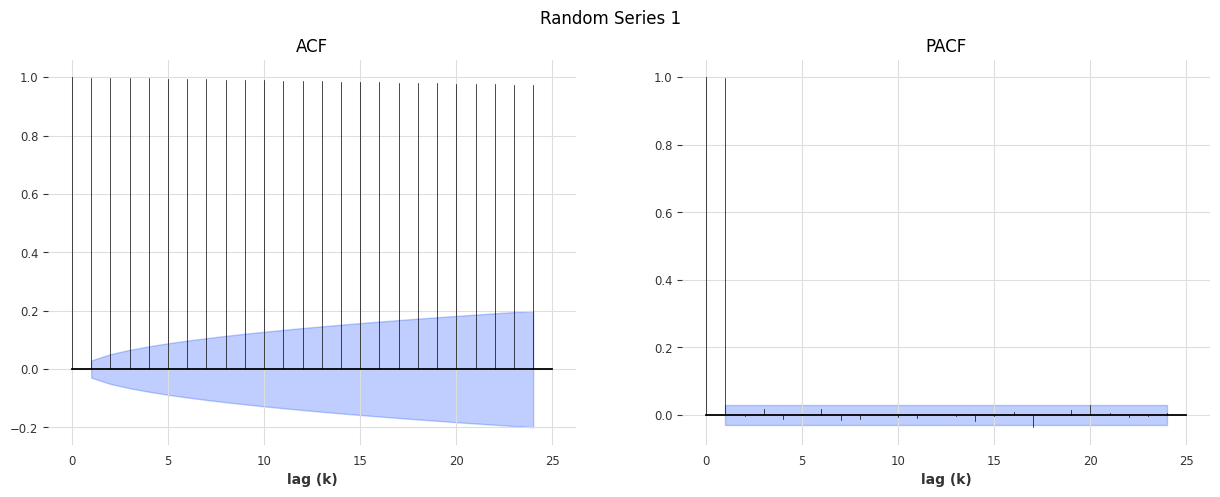

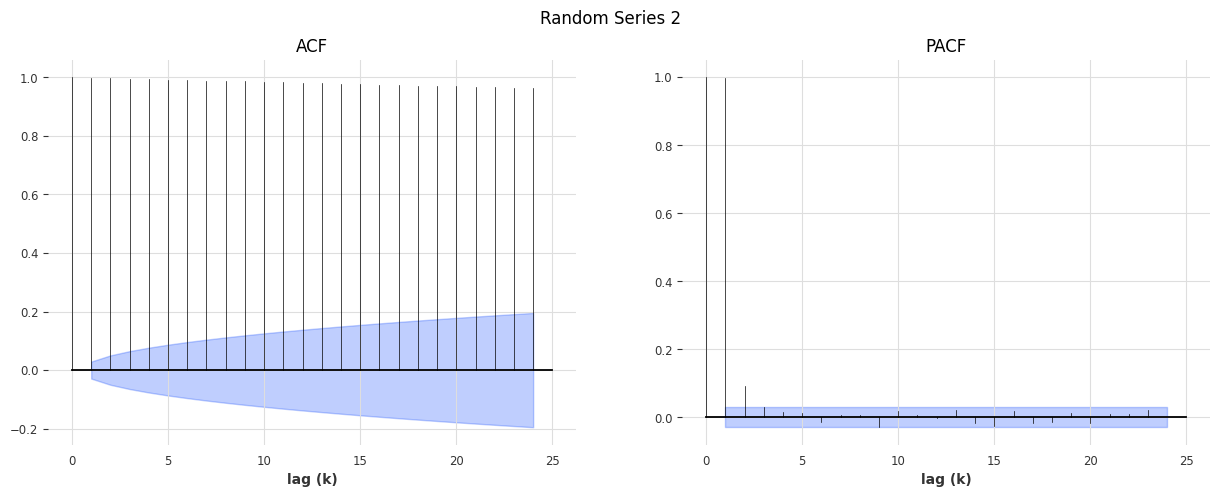

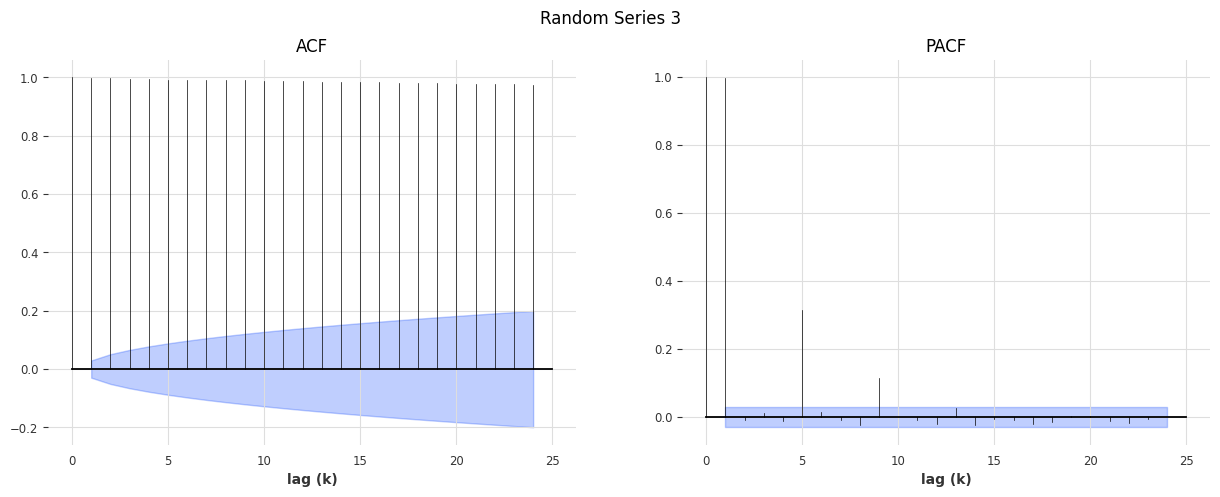

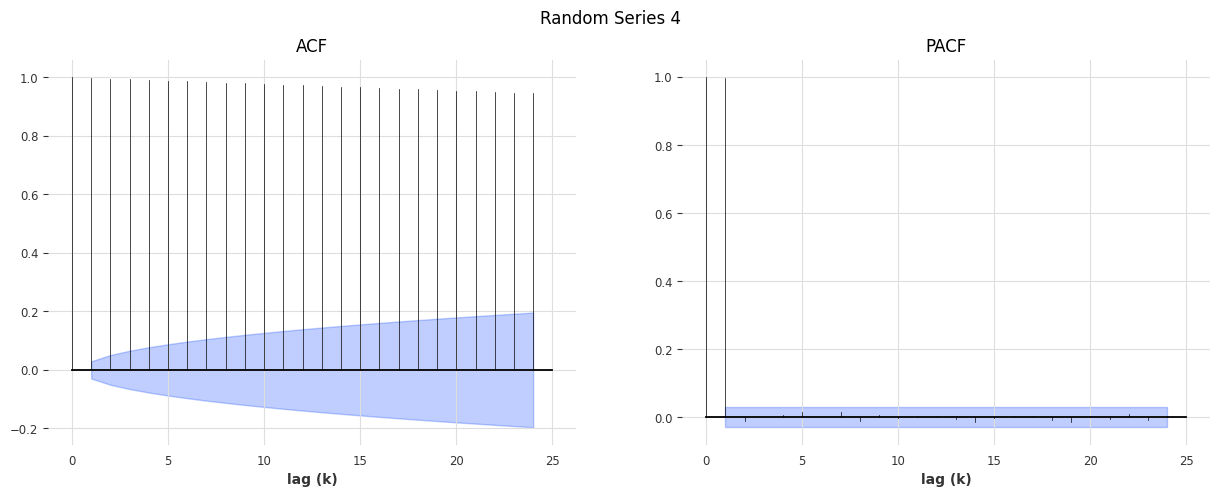

In [113]:
for i, series in enumerate(random_series_list, start=1):
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    fig.suptitle(f'Random Series {i}')
    plot_acf(series,axis=axes[0])
    axes[0].set_title('ACF')
    axes[0].set_xlabel('lag (k)')
    plot_pacf(series,axis=axes[1])
    axes[1].set_title('PACF')
    axes[1].set_xlabel('lag (k)')

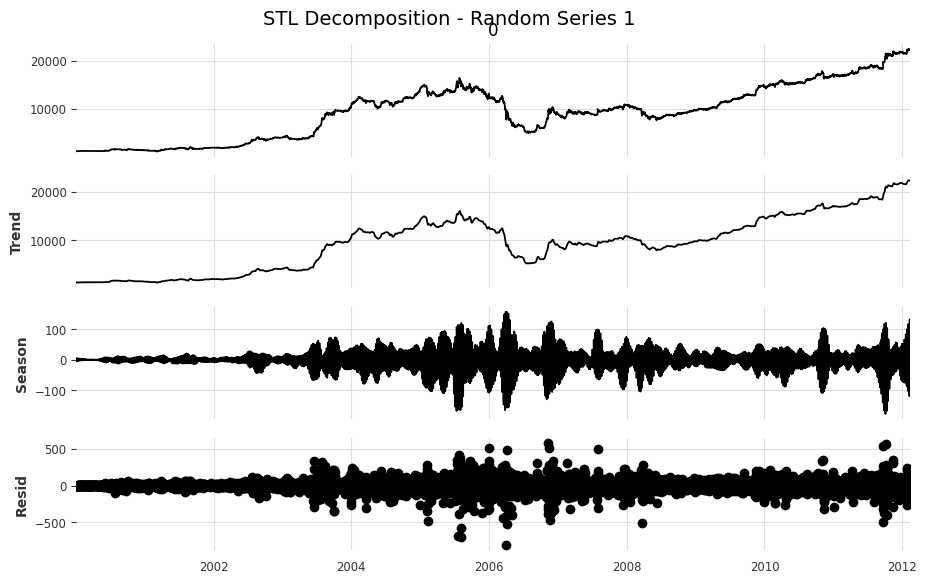

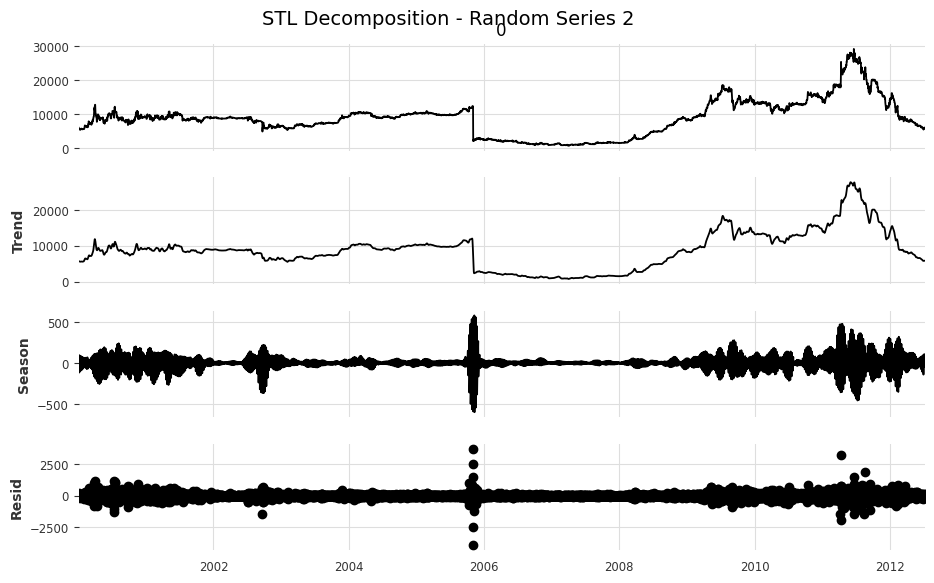

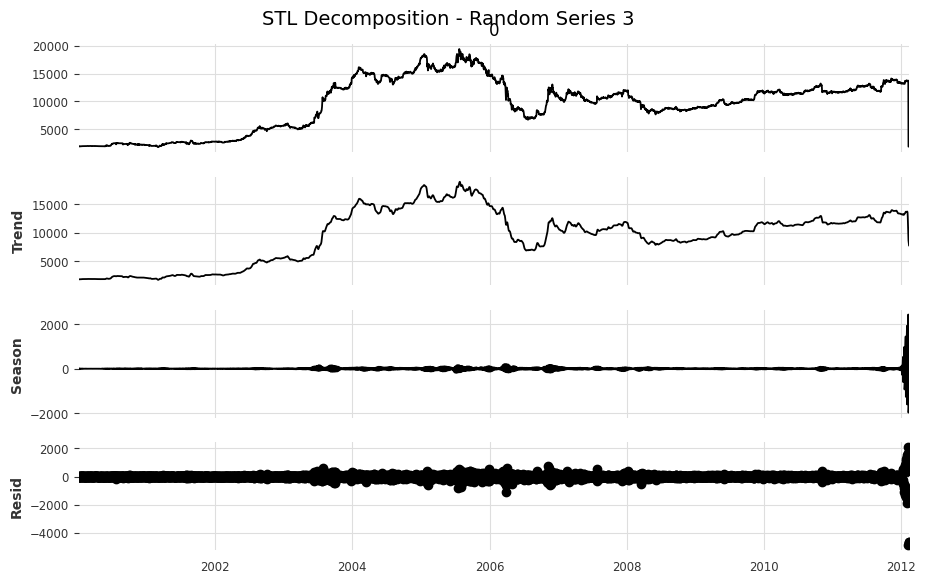

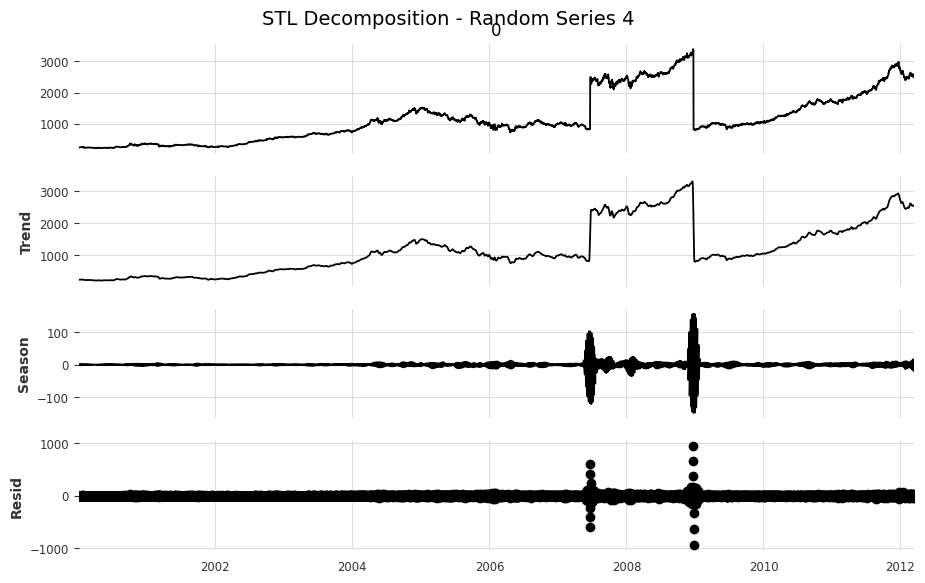

In [116]:
for i, series in enumerate(random_series_list, start=1):
    # Convert Darts TimeSeries to pandas Series
    ts_values = series.to_series()

    # Perform STL decomposition
    stl = STL(ts_values, seasonal=13)  # seasonal=13 for weekly seasonality in daily data
    result = stl.fit()

    # Plot STL decomposition
    fig = result.plot()
    fig.set_size_inches(10, 6)
    fig.suptitle(f'STL Decomposition - Random Series {i}', fontsize=14)
    plt.show()

In [123]:
for i, series in enumerate(random_series_list, start=1):
     # Outlier Detection
    z_scores = (values - np.mean(values)) / np.std(values)
    outliers = np.where(np.abs(z_scores) > 3)[0]
    print("Outlier indices:", outliers)

Outlier indices: []
Outlier indices: []
Outlier indices: []
Outlier indices: []
